In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

PAIRS      = ['EURUSD', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']
DATA_PATH  = '/content/drive/MyDrive/MR_ML/{pair}/{pair}_M1.csv'

print('Imports done.')
print(f'Pairs: {PAIRS}')

Imports done.
Pairs: ['EURUSD', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']


In [ ]:
def load_pair(pair):
    path = DATA_PATH.format(pair=pair)
    df   = pd.read_csv(path)
    df['datetime'] = pd.to_datetime(
        df['Date'].astype(str) + ' ' + df['Time'],
        format='%Y%m%d %H:%M:%S'
    )
    df = df.sort_values('datetime').set_index('datetime')
    return df[['Open','High','Low','Close']]

def resample_ohlc(data, tf):
    return data.resample(tf).agg({
        'Open':  'first',
        'High':  'max',
        'Low':   'min',
        'Close': 'last'
    }).dropna()

data_4h = {}

for pair in PAIRS:
    try:
        raw           = load_pair(pair)
        data_4h[pair] = resample_ohlc(raw, '4h')
        print(f'{pair}: {len(data_4h[pair])} 4H candles | '
              f'{data_4h[pair].index.min().date()} -> '
              f'{data_4h[pair].index.max().date()}')
    except Exception as e:
        print(f'{pair}: FAILED — {e}')

EURUSD: 34103 4H candles | 2005-01-03 -> 2026-02-22
GBPUSD: 34101 4H candles | 2005-01-03 -> 2026-02-22
NZDUSD: 34093 4H candles | 2005-01-03 -> 2026-02-22
USDCAD: 34101 4H candles | 2005-01-03 -> 2026-02-22
USDCHF: 34102 4H candles | 2005-01-03 -> 2026-02-22
USDJPY: 34102 4H candles | 2005-01-03 -> 2026-02-22


In [ ]:
def calc_atr(data, period=14):
    tr1 = data['High'] - data['Low']
    tr2 = (data['High'] - data['Close'].shift()).abs()
    tr3 = (data['Low']  - data['Close'].shift()).abs()
    tr  = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr, tr.rolling(period).mean()

def calc_adx(data, tr, period=14):
    up   = data['High'].diff()
    down = -data['Low'].diff()
    pdm  = pd.Series(
        np.where((up > down) & (up > 0), up, 0), index=data.index
    )
    mdm  = pd.Series(
        np.where((down > up) & (down > 0), down, 0), index=data.index
    )
    tr14 = tr.rolling(period).sum()
    pdi  = 100 * (pdm.rolling(period).sum() / tr14)
    mdi  = 100 * (mdm.rolling(period).sum() / tr14)
    dx   = 100 * (abs(pdi - mdi) / (pdi + mdi))
    return dx.rolling(period).mean(), pdi, mdi

def calc_hurst(series):
    try:
        lags = range(2, 20)
        tau  = [np.std(series.diff(lag).dropna()) for lag in lags]
        if any(t == 0 for t in tau):
            return np.nan
        poly = np.polyfit(np.log(lags), np.log(tau), 1)
        return poly[0] * 2.0
    except:
        return np.nan

def calc_efficiency_ratio(close, period=14):
    net  = abs(close - close.shift(period))
    path = close.diff().abs().rolling(period).sum()
    return net / path.replace(0, np.nan)

def calc_ar1(series):
    """AR(1) coefficient — high = trending, negative = mean reverting"""
    try:
        y = series.values
        return np.corrcoef(y[:-1], y[1:])[0, 1]
    except:
        return np.nan

def calc_adf_pval(series):
    """ADF p-value — low p = stationary = ranging"""
    try:
        return adfuller(series, maxlag=1, autolag=None)[1]
    except:
        return np.nan

def calc_ou_halflife(series):
    """OU half-life — short = fast mean reversion = ranging"""
    try:
        delta = np.diff(series)
        lag   = series[:-1]
        beta  = np.polyfit(lag, delta, 1)[0]
        if beta >= 0:
            return 999.0
        return min(-np.log(2) / beta, 999.0)
    except:
        return np.nan

print('All indicator functions ready.')

All indicator functions ready.


In [ ]:
def build_features_and_labels(pair):
    d = data_4h[pair].copy()

    # Base indicators
    tr, d['atr']                           = calc_atr(d)
    d['adx'], d['plus_di'], d['minus_di']  = calc_adx(d, tr)
    ma                                      = d['Close'].rolling(20).mean()
    std                                     = d['Close'].rolling(20).std()
    d['bb_width']                           = (4 * std) / d['Close']
    d['ma_50']                              = d['Close'].rolling(50).mean()
    d['hurst']                              = d['Close'].rolling(40).apply(
        lambda x: calc_hurst(x), raw=False
    )

    # ── Features ──
    feat = pd.DataFrame(index=d.index)

    # ADX family
    feat['adx']          = d['adx']
    feat['adx_slope']    = d['adx'].diff(3)
    feat['adx_accel']    = d['adx'].diff(3).diff(3)
    feat['di_spread']    = abs(d['plus_di'] - d['minus_di'])

    # Bollinger
    feat['bb_width']     = d['bb_width']
    feat['bb_slope']     = d['bb_width'].diff(3)

    # Hurst
    feat['hurst']        = d['hurst']
    feat['hurst_slope']  = d['hurst'].diff(3)

    # Efficiency Ratio (current, not forward)
    feat['er_10']        = calc_efficiency_ratio(d['Close'], 10)
    feat['er_20']        = calc_efficiency_ratio(d['Close'], 20)
    feat['er_slope']     = feat['er_10'].diff(3)

    # AR(1)
    feat['ar1']          = d['Close'].rolling(20).apply(
        lambda x: calc_ar1(x), raw=False
    )

    # ADF p-value
    feat['adf_pval']     = d['Close'].rolling(30).apply(
        lambda x: calc_adf_pval(x), raw=False
    )

    # OU half-life
    feat['ou_halflife']  = d['Close'].rolling(30).apply(
        lambda x: calc_ou_halflife(x), raw=False
    ).clip(0, 200)

    # Volatility
    feat['vol_ratio']    = d['atr'] / d['atr'].rolling(50).mean()
    feat['atr_slope']    = d['atr'].diff(3)

    # Price position
    feat['price_vs_ma']  = (d['Close'] - d['ma_50']) / d['atr']

    # Directional consistency
    direction            = (d['Close'] > d['Open']).astype(int) * 2 - 1
    feat['dir_consist']  = direction.rolling(5).sum().abs()
    feat['ret_vol']      = d['Close'].pct_change().rolling(10).std()

    # ── Labels — current structure only, no future data ──
    # Trending = at least 3 of 4 current indicators agree

    cond_adx   = (d['adx'] > 25).astype(int)
    cond_bb    = (d['bb_width'] > d['bb_width'].rolling(20).mean()).astype(int)
    cond_hurst = (d['hurst'] > 0.55).astype(int)
    cond_er    = (feat['er_10'] > feat['er_10'].rolling(20).mean()).astype(int)

    trending   = ((cond_adx + cond_bb + cond_hurst + cond_er) >= 3).astype(int)

    # Direction — which side of 50MA is price on?
    trend_up   = (trending == 1) & (d['Close'] > d['ma_50'])
    trend_down = (trending == 1) & (d['Close'] < d['ma_50'])

    labels               = pd.DataFrame(index=d.index)
    labels['trending']   = trending
    labels['trend_up']   = trend_up.astype(int)
    labels['trend_down'] = trend_down.astype(int)
    labels['regime_3']   = np.where(
        labels['trend_up']   == 1, 1,
        np.where(labels['trend_down'] == 1, 2, 0)
    )

    combined             = feat.join(labels).dropna()
    combined['pair']     = pair
    return combined

# Build for all pairs
all_data_list = []
for pair in PAIRS:
    print(f'Building {pair}...', end=' ')
    d = build_features_and_labels(pair)
    all_data_list.append(d)
    trend_pct = d['trending'].mean()
    print(f'{len(d):,} samples | trending={trend_pct:.1%} | ranging={1-trend_pct:.1%}')

all_data = pd.concat(all_data_list)

print(f'\nTotal samples (all pairs): {len(all_data):,}')
print(f'Overall trending: {all_data["trending"].mean():.2%}')
print(f'Overall ranging : {(1-all_data["trending"]).mean():.2%}')
print(f'\nRegime 3-class distribution:')
print(all_data['regime_3'].value_counts(normalize=True)
      .rename({0:'Ranging', 1:'Trend Up', 2:'Trend Down'}))

Building EURUSD... 34,041 samples | trending=36.4% | ranging=63.6%
Building GBPUSD... 34,039 samples | trending=36.3% | ranging=63.7%
Building NZDUSD... 34,031 samples | trending=34.5% | ranging=65.5%
Building USDCAD... 34,039 samples | trending=35.5% | ranging=64.5%
Building USDCHF... 34,040 samples | trending=35.2% | ranging=64.8%
Building USDJPY... 34,040 samples | trending=36.3% | ranging=63.7%

Total samples (all pairs): 204,230
Overall trending: 35.69%
Overall ranging : 64.31%

Regime 3-class distribution:
regime_3
Ranging       0.643084
Trend Down    0.178715
Trend Up      0.178201
Name: proportion, dtype: float64


In [ ]:
FEATURE_COLS = [
    'adx','adx_slope','adx_accel','di_spread',
    'bb_width','bb_slope',
    'hurst','hurst_slope',
    'er_10','er_20','er_slope',
    'ar1','adf_pval','ou_halflife',
    'vol_ratio','atr_slope',
    'price_vs_ma','dir_consist','ret_vol'
]

X = all_data[FEATURE_COLS]
y = all_data['trending']

# Time-based split — no shuffle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train trending rate: {y_train.mean():.2%}')
print(f'Test  trending rate: {y_test.mean():.2%}')
print()

# ── Random Forest ──
rf = RandomForestClassifier(
    n_estimators=300, max_depth=6,
    min_samples_leaf=30, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

print('=== Random Forest ===')
print(f'Train Accuracy : {rf.score(X_train, y_train):.4f}')
print(f'Test Accuracy  : {rf.score(X_test, y_test):.4f}')
print(f'Test AUC       : {rf_auc:.4f}')
print(classification_report(y_test, rf.predict(X_test),
      target_names=['Ranging','Trending']))

# ── Gradient Boosting ──
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)

gb_proba = gb.predict_proba(X_test)[:, 1]
gb_auc   = roc_auc_score(y_test, gb_proba)

print('=== Gradient Boosting ===')
print(f'Train Accuracy : {gb.score(X_train, y_train):.4f}')
print(f'Test Accuracy  : {gb.score(X_test, y_test):.4f}')
print(f'Test AUC       : {gb_auc:.4f}')
print(classification_report(y_test, gb.predict(X_test),
      target_names=['Ranging','Trending']))

# Pick best model
BEST_MODEL      = rf if rf_auc >= gb_auc else gb
BEST_MODEL_NAME = 'Random Forest' if rf_auc >= gb_auc else 'Gradient Boosting'
print(f'\nBest model: {BEST_MODEL_NAME} (AUC={max(rf_auc, gb_auc):.4f}')

Train: 142,961 | Test: 61,269
Train trending rate: 35.67%
Test  trending rate: 35.74%

=== Random Forest ===
Train Accuracy : 0.8984
Test Accuracy  : 0.8967
Test AUC       : 0.9638
              precision    recall  f1-score   support

     Ranging       0.94      0.90      0.92     39372
    Trending       0.83      0.90      0.86     21897

    accuracy                           0.90     61269
   macro avg       0.88      0.90      0.89     61269
weighted avg       0.90      0.90      0.90     61269

=== Gradient Boosting ===
Train Accuracy : 0.9290
Test Accuracy  : 0.9242
Test AUC       : 0.9810
              precision    recall  f1-score   support

     Ranging       0.94      0.95      0.94     39372
    Trending       0.90      0.88      0.89     21897

    accuracy                           0.92     61269
   macro avg       0.92      0.92      0.92     61269
weighted avg       0.92      0.92      0.92     61269


Best model: Gradient Boosting (AUC=0.9810


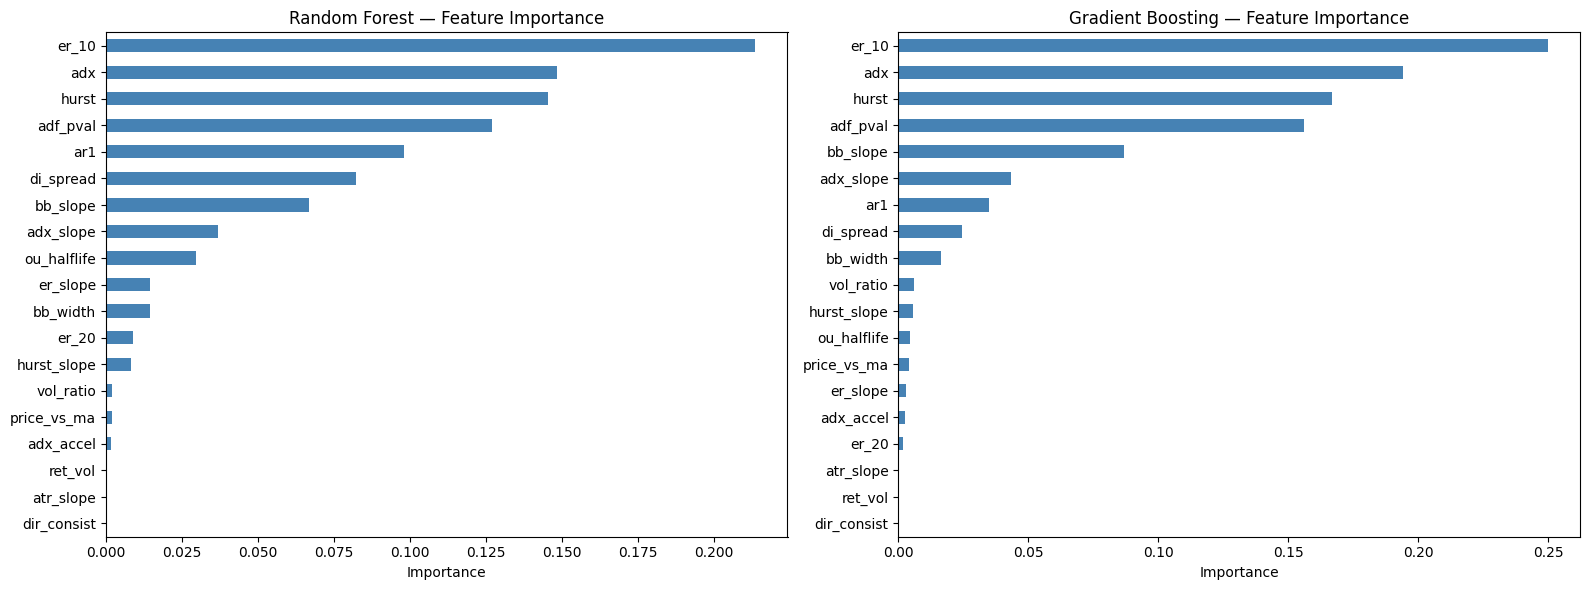

Top 10 features (Random Forest):
er_10          0.2135
adx            0.1482
hurst          0.1453
adf_pval       0.1270
ar1            0.0979
di_spread      0.0823
bb_slope       0.0667
adx_slope      0.0369
ou_halflife    0.0298
er_slope       0.0145
dtype: float64

Top 10 features (Gradient Boosting):
er_10        0.2497
adx          0.1941
hurst        0.1667
adf_pval     0.1562
bb_slope     0.0869
adx_slope    0.0433
ar1          0.0347
di_spread    0.0243
bb_width     0.0164
vol_ratio    0.0061
dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, name in [
    (axes[0], rf, 'Random Forest'),
    (axes[1], gb, 'Gradient Boosting')
]:
    imp = pd.Series(model.feature_importances_,
                    index=FEATURE_COLS).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Feature Importance')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('Top 10 features (Random Forest):')
rf_imp = pd.Series(rf.feature_importances_,
                   index=FEATURE_COLS).sort_values(ascending=False)
print(rf_imp.head(10).round(4))

print('\nTop 10 features (Gradient Boosting):')
gb_imp = pd.Series(gb.feature_importances_,
                   index=FEATURE_COLS).sort_values(ascending=False)
print(gb_imp.head(10).round(4))

In [ ]:
# Attach predictions back to data
all_data['rf_prob']    = rf.predict_proba(X)[:, 1]
all_data['gb_prob']    = gb.predict_proba(X)[:, 1]
all_data['rf_pred']    = (all_data['rf_prob'] > 0.5).astype(int)
all_data['gb_pred']    = (all_data['gb_prob'] > 0.5).astype(int)

print('=== Indicator Separation by Predicted Regime (Best Model) ===')
print()

prob_col = 'rf_prob' if BEST_MODEL_NAME == 'Random Forest' else 'gb_prob'

gb_threshold = all_data[prob_col].mean() + all_data[prob_col].std()
print(f'Using adaptive threshold: {gb_threshold:.3f}')
trend_on  = all_data[all_data[prob_col] > gb_threshold]
trend_off = all_data[all_data[prob_col] <= gb_threshold]

print(f'Trend ON  (prob > 0.57): {len(trend_on):,} samples ({len(trend_on)/len(all_data):.1%})')
print(f'Trend OFF (prob <= 0.57): {len(trend_off):,} samples ({len(trend_off)/len(all_data):.1%})')
print()

indicators = ['adx','bb_width','hurst','er_10','ar1','vol_ratio']
print(f"{'Indicator':<15} {'Trend ON':>12} {'Trend OFF':>12} {'Separation':>12}")
print('-' * 55)
for col in indicators:
    if col not in all_data.columns:
        continue
    on_val  = trend_on[col].mean()
    off_val = trend_off[col].mean()
    sep     = (on_val - off_val) / abs(off_val) * 100 if off_val != 0 else 0
    print(f'{col:<15} {on_val:>12.4f} {off_val:>12.4f} {sep:>+11.1f}%')

# Per pair AUC
print(f'\n=== AUC per pair ===')
for pair in PAIRS:
    pair_data = all_data[all_data['pair'] == pair]
    if len(pair_data) < 100:
        continue
    auc = roc_auc_score(pair_data['trending'], pair_data[prob_col])
    print(f'  {pair}: AUC={auc:.4f} | n={len(pair_data):,}')

# Probability distribution
print(f'\n=== Probability distribution ===')
print(all_data[prob_col].describe().round(4))
print(f'Std: {all_data[prob_col].std():.4f}  (want > 0.15 for useful separation)')

# Coverage at different thresholds
print(f'\n=== Coverage at different thresholds ===')
for t in [0.40, 0.45, 0.50, 0.55, 0.57, 0.60, 0.65]:
    pct = (all_data[prob_col] > t).mean()
    # Precision at threshold
    subset = all_data[all_data[prob_col] > t]
    prec   = subset['trending'].mean() if len(subset) > 0 else 0
    print(f'  prob > {t}: {pct:.2%} of candles | '
          f'actual trend rate = {prec:.2%}')

=== Indicator Separation by Predicted Regime (Best Model) ===

Using adaptive threshold: 0.759
Trend ON  (prob > 0.57): 57,123 samples (28.0%)
Trend OFF (prob <= 0.57): 147,107 samples (72.0%)

Indicator           Trend ON    Trend OFF   Separation
-------------------------------------------------------
adx                  45.2536      33.4844       +35.1%
bb_width              0.0217       0.0130       +66.1%
hurst                 0.6935       0.3730       +85.9%
er_10                 0.5476       0.2664      +105.5%
ar1                   0.8786       0.7043       +24.8%
vol_ratio             1.0605       0.9841        +7.8%

=== AUC per pair ===
  EURUSD: AUC=0.9825 | n=34,041
  GBPUSD: AUC=0.9826 | n=34,039
  NZDUSD: AUC=0.9843 | n=34,031
  USDCAD: AUC=0.9827 | n=34,039
  USDCHF: AUC=0.9820 | n=34,040
  USDJPY: AUC=0.9801 | n=34,040

=== Probability distribution ===
count    204230.0000
mean          0.3562
std           0.4025
min           0.0006
25%           0.0107
50%         

In [ ]:
X3 = all_data[FEATURE_COLS]
y3 = all_data['regime_3']  # 0=ranging, 1=trend_up, 2=trend_down

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.3, shuffle=False
)

rf3 = RandomForestClassifier(
    n_estimators=300, max_depth=6,
    min_samples_leaf=30, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf3.fit(X3_train, y3_train)

print('=== 3-Class Model (Ranging / Trend Up / Trend Down) ===')
print(f'Train Accuracy: {rf3.score(X3_train, y3_train):.4f}')
print(f'Test Accuracy : {rf3.score(X3_test, y3_test):.4f}')
print(classification_report(
    y3_test, rf3.predict(X3_test),
    target_names=['Ranging','Trend Up','Trend Down']
))

# Attach 3-class probabilities
proba3 = rf3.predict_proba(X3)
all_data['prob_ranging']    = proba3[:, 0]
all_data['prob_trend_up']   = proba3[:, 1]
all_data['prob_trend_down'] = proba3[:, 2]
all_data['pred_regime_3']   = rf3.predict(X3)

print(f'\nPredicted regime distribution:')
print(pd.Series(rf3.predict(X3)).value_counts(normalize=True)
      .rename({0:'Ranging', 1:'Trend Up', 2:'Trend Down'}))

=== 3-Class Model (Ranging / Trend Up / Trend Down) ===
Train Accuracy: 0.8657
Test Accuracy : 0.8651
              precision    recall  f1-score   support

     Ranging       0.97      0.82      0.89     39372
    Trend Up       0.73      0.95      0.83     11196
  Trend Down       0.76      0.95      0.84     10701

    accuracy                           0.87     61269
   macro avg       0.82      0.91      0.85     61269
weighted avg       0.89      0.87      0.87     61269


Predicted regime distribution:
Ranging       0.540087
Trend Up      0.231416
Trend Down    0.228497
Name: proportion, dtype: float64


In [ ]:
print('=== Regime Persistence Analysis ===')
print()

for pair in PAIRS:
    pair_data = all_data[all_data['pair'] == pair].copy()

    # Trending — from gb_model output
    trend_regime = (pair_data['gb_prob'] > 0.90).astype(int)

    # Ranging — from rf3 output
    range_regime = (pair_data['prob_ranging'] > 0.80).astype(int)

    for label, regime in [('Trending', trend_regime), ('Ranging', range_regime)]:
        runs = (regime != regime.shift()).cumsum()
        active_blocks = regime.groupby(runs).apply(
            lambda x: len(x) if x.iloc[0] == 1 else None
        ).dropna()
        avg_dur = active_blocks.mean()
        persist = (regime == regime.shift()).mean()
        print(f'{pair} {label}: same next candle={persist:.2%} | '
              f'avg duration={avg_dur:.1f} candles ({avg_dur*4:.0f} hours)')
    print()

=== Regime Persistence Analysis ===

EURUSD Trending: same next candle=91.15% | avg duration=5.0 candles (20 hours)
EURUSD Ranging: same next candle=89.00% | avg duration=4.7 candles (19 hours)

GBPUSD Trending: same next candle=90.88% | avg duration=4.8 candles (19 hours)
GBPUSD Ranging: same next candle=89.09% | avg duration=4.7 candles (19 hours)

NZDUSD Trending: same next candle=91.16% | avg duration=4.9 candles (20 hours)
NZDUSD Ranging: same next candle=89.00% | avg duration=4.9 candles (20 hours)

USDCAD Trending: same next candle=91.49% | avg duration=4.8 candles (19 hours)
USDCAD Ranging: same next candle=88.23% | avg duration=4.7 candles (19 hours)

USDCHF Trending: same next candle=91.55% | avg duration=5.0 candles (20 hours)
USDCHF Ranging: same next candle=89.03% | avg duration=5.0 candles (20 hours)

USDJPY Trending: same next candle=91.17% | avg duration=4.9 candles (20 hours)
USDJPY Ranging: same next candle=89.22% | avg duration=4.9 candles (19 hours)



In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Step 1: Find the cleanest year/pair combination ──
print("Finding cleanest period (highest std = most decisive regime calls):\n")
best_std = 0
best_pair = ''
best_year = ''

for pair in ['USDCAD', 'USDCHF', 'EURUSD', 'GBPUSD']:
    for year in ['2019', '2020', '2021', '2022']:
        subset = all_data[all_data['pair'] == pair]
        mask = subset.index.year == int(year)
        if mask.sum() < 100:
            continue
        avg_prob = subset[mask]['prob_ranging'].mean()
        std_prob = subset[mask]['prob_ranging'].std()
        print(f'{pair} {year}: avg_ranging={avg_prob:.2f} | std={std_prob:.2f}')
        if std_prob > best_std:
            best_std = std_prob
            best_pair = pair
            best_year = year

print(f'\nBest combination: {best_pair} {best_year} (std={best_std:.2f})')

Finding cleanest period (highest std = most decisive regime calls):

USDCAD 2019: avg_ranging=0.51 | std=0.33
USDCAD 2020: avg_ranging=0.54 | std=0.33
USDCAD 2021: avg_ranging=0.51 | std=0.34
USDCAD 2022: avg_ranging=0.54 | std=0.33
USDCHF 2019: avg_ranging=0.53 | std=0.33
USDCHF 2020: avg_ranging=0.49 | std=0.34
USDCHF 2021: avg_ranging=0.56 | std=0.33
USDCHF 2022: avg_ranging=0.48 | std=0.32
EURUSD 2019: avg_ranging=0.51 | std=0.33
EURUSD 2020: avg_ranging=0.45 | std=0.32
EURUSD 2021: avg_ranging=0.52 | std=0.33
EURUSD 2022: avg_ranging=0.53 | std=0.34
GBPUSD 2019: avg_ranging=0.49 | std=0.33
GBPUSD 2020: avg_ranging=0.47 | std=0.32
GBPUSD 2021: avg_ranging=0.51 | std=0.34
GBPUSD 2022: avg_ranging=0.51 | std=0.32

Best combination: GBPUSD 2021 (std=0.34)


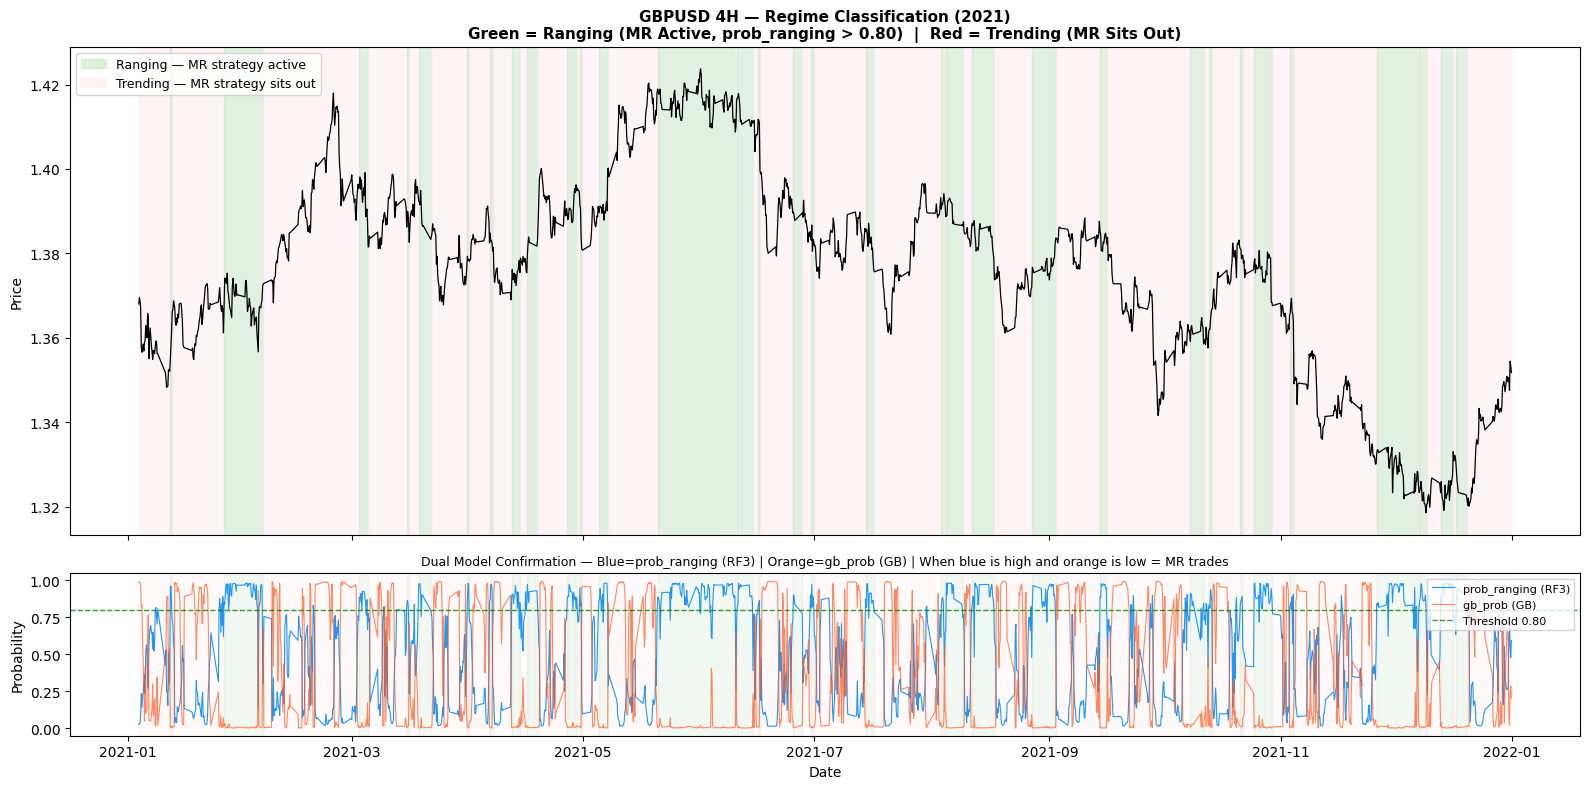

Saved to /content/drive/MyDrive/MR_ML/regime_overlay_GBPUSD_2021_v3.png


In [ ]:
# ── Step 2: Plot with that pair/year ──
# Change these two lines based on Step 1 output
pair = best_pair
year = best_year

features = all_data[all_data['pair'] == pair].copy()
features['Close'] = data_4h[pair]['Close']

mask = features.index.year == int(year)
plot_data = features[mask].dropna(subset=['Close', 'prob_ranging'])

# ── Aggressive smoothing ──
raw_ranging = (plot_data['prob_ranging'] > 0.80).astype(int).values.copy()

# Pass 1: remove runs shorter than 3 candles
i = 0
while i < len(raw_ranging):
    current = raw_ranging[i]
    j = i
    while j < len(raw_ranging) and raw_ranging[j] == current:
        j += 1
    run_length = j - i
    if run_length < 3 and i > 0:
        raw_ranging[i:j] = raw_ranging[i-1]
    i = j

# Pass 2: run again to catch any new short runs created by pass 1
i = 0
while i < len(raw_ranging):
    current = raw_ranging[i]
    j = i
    while j < len(raw_ranging) and raw_ranging[j] == current:
        j += 1
    run_length = j - i
    if run_length < 3 and i > 0:
        raw_ranging[i:j] = raw_ranging[i-1]
    i = j

ranging = raw_ranging.astype(bool)

# ── Build regime blocks ──
blocks = []
start_idx = 0
current = ranging[0]

for i in range(1, len(ranging)):
    if ranging[i] != current:
        blocks.append((plot_data.index[start_idx],
                       plot_data.index[i],
                       current))
        start_idx = i
        current = ranging[i]
blocks.append((plot_data.index[start_idx],
               plot_data.index[-1],
               current))

# ── Plot ──
fig, axes = plt.subplots(2, 1, figsize=(16, 8),
                          gridspec_kw={'height_ratios': [3, 1]},
                          sharex=True)

# Top panel: price + regime shading
ax = axes[0]
ax.plot(plot_data.index, plot_data['Close'],
        color='black', linewidth=0.9, zorder=3)

for (start, end, is_ranging) in blocks:
    color = '#c8e6c9' if is_ranging else '#ffebee'
    ax.axvspan(start, end, alpha=0.55, color=color, zorder=1)

ax.set_title(f'{pair} 4H — Regime Classification ({year})\n'
             f'Green = Ranging (MR Active, prob_ranging > 0.80)  |  '
             f'Red = Trending (MR Sits Out)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Price')

ranging_patch  = mpatches.Patch(color='#c8e6c9', alpha=0.6,
                                 label='Ranging — MR strategy active')
trending_patch = mpatches.Patch(color='#ffebee', alpha=0.6,
                                 label='Trending — MR strategy sits out')
ax.legend(handles=[ranging_patch, trending_patch],
          loc='upper left', fontsize=9)

# Bottom panel: both model probabilities
ax2 = axes[1]
ax2.plot(plot_data.index, plot_data['prob_ranging'],
         color='#2196F3', linewidth=0.8, label='prob_ranging (RF3)')
ax2.plot(plot_data.index, plot_data['gb_prob'],
         color='#FF5722', linewidth=0.8, alpha=0.7, label='gb_prob (GB)')
ax2.axhline(y=0.80, color='green', linewidth=1.0,
            linestyle='--', alpha=0.8, label='Threshold 0.80')

# Shade the bottom panel too for consistency
for (start, end, is_ranging) in blocks:
    color = '#c8e6c9' if is_ranging else '#ffebee'
    ax2.axvspan(start, end, alpha=0.25, color=color, zorder=1)

ax2.set_ylabel('Probability')
ax2.set_xlabel('Date')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper right', fontsize=8)
ax2.set_title('Dual Model Confirmation — Blue=prob_ranging (RF3) | '
              'Orange=gb_prob (GB) | When blue is high and orange is low = MR trades',
              fontsize=9)

plt.tight_layout()

save_path = f'/content/drive/MyDrive/MR_ML/regime_overlay_{pair}_{year}_v3.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

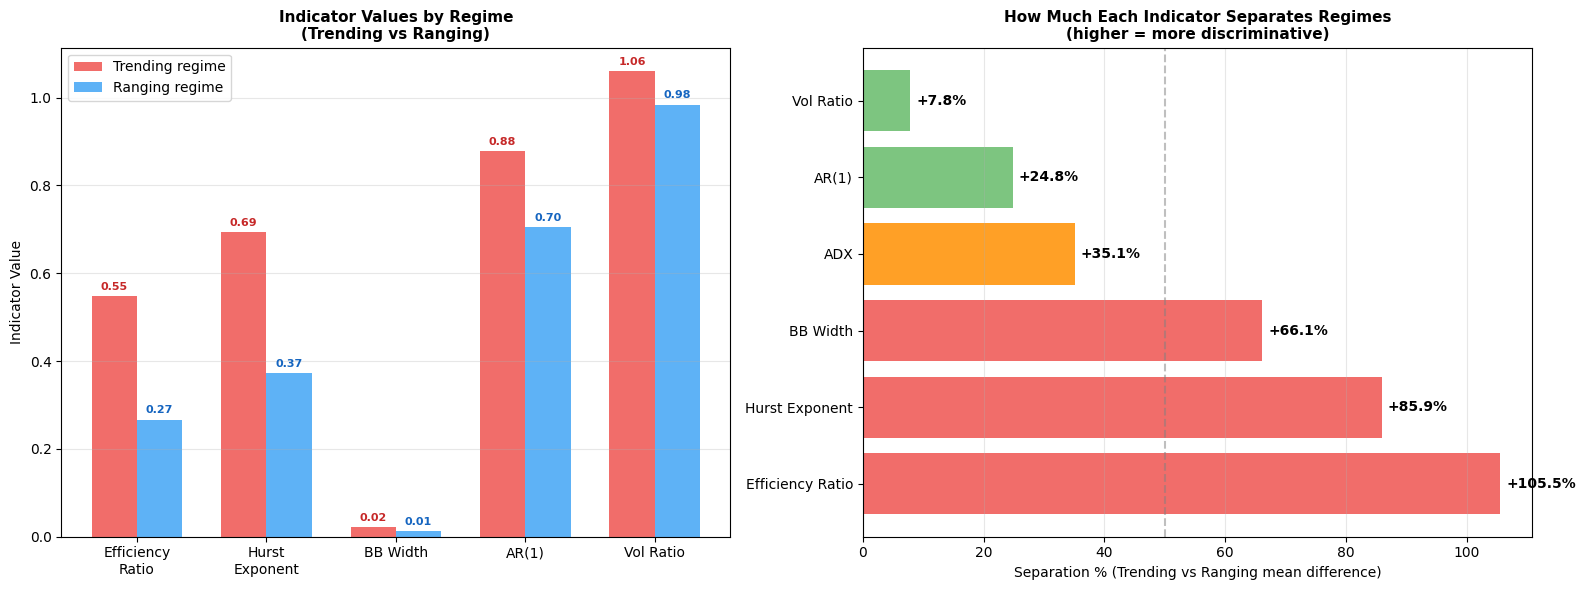

Chart 1 saved.


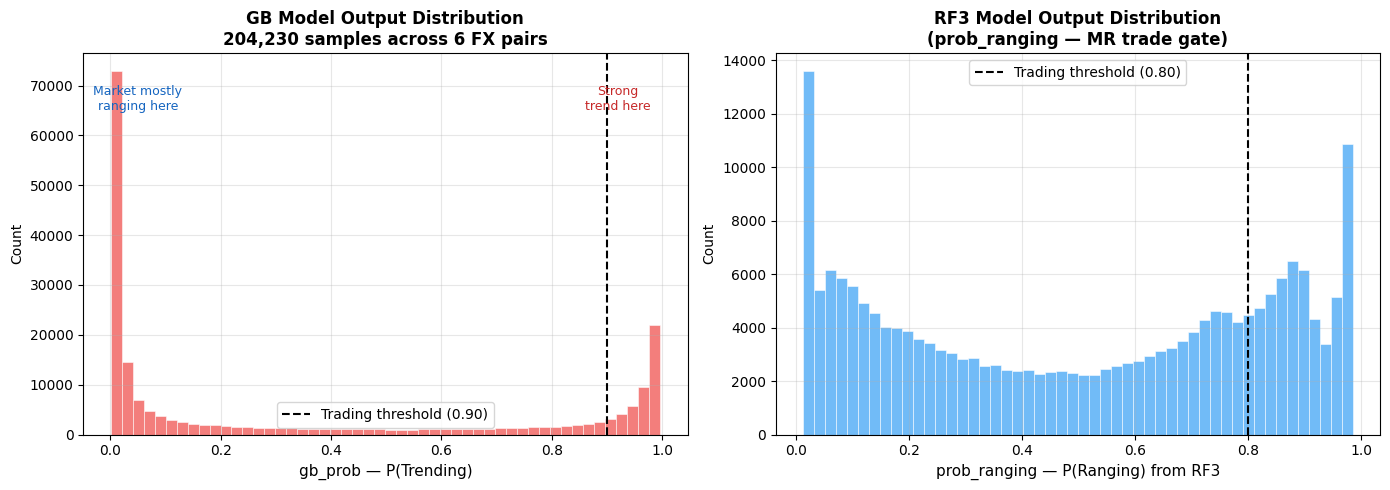

Chart 2 saved.


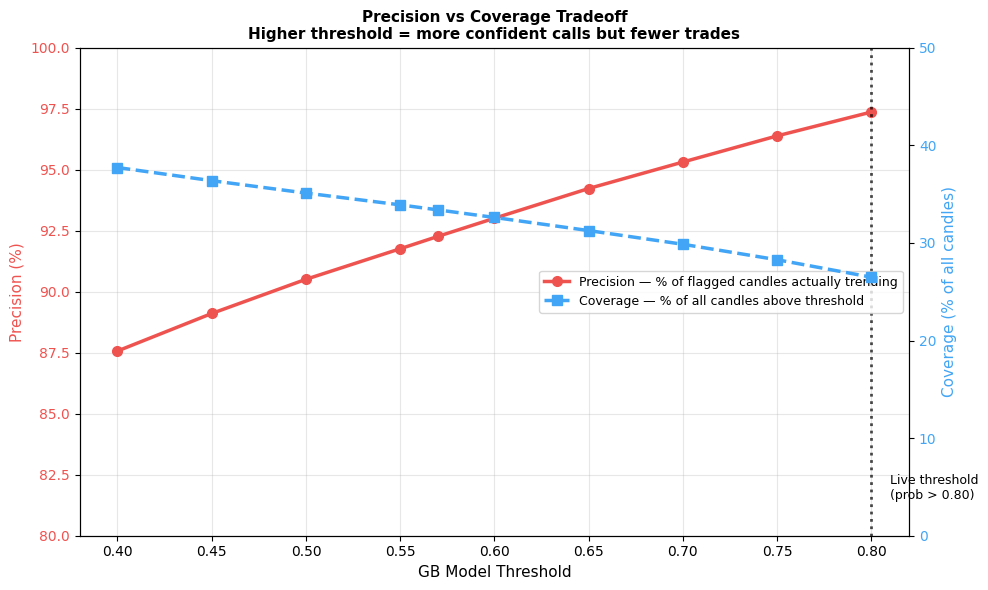

Chart 3 saved.

All 3 charts saved to Google Drive.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ============================================================
# CHART 1: Indicator Separation Bar Chart
# ============================================================

indicators = {
    'Efficiency\nRatio': (0.5476, 0.2664),
    'Hurst\nExponent': (0.6935, 0.3730),
    'BB Width':         (0.0217, 0.0130),
    'ADX':              (45.25,  33.48),
    'AR(1)':            (0.8786, 0.7043),
    'Vol Ratio':        (1.0605, 0.9841),
}

# Normalize to 0-1 scale for visual comparison
# (ADX is on different scale so we normalize each)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: raw values side by side
ax = axes[0]
x = np.arange(len(indicators))
width = 0.35
labels = list(indicators.keys())

# Skip ADX for raw chart (different scale) — show 5 normalized ones
norm_indicators = {k: v for k, v in indicators.items() if k != 'ADX'}
x2 = np.arange(len(norm_indicators))
trend_vals = [v[0] for v in norm_indicators.values()]
range_vals  = [v[1] for v in norm_indicators.values()]
norm_labels = list(norm_indicators.keys())

bars1 = ax.bar(x2 - width/2, trend_vals, width,
               label='Trending regime', color='#ef5350', alpha=0.85)
bars2 = ax.bar(x2 + width/2, range_vals, width,
               label='Ranging regime', color='#42a5f5', alpha=0.85)

ax.set_xticks(x2)
ax.set_xticklabels(norm_labels, fontsize=10)
ax.set_ylabel('Indicator Value')
ax.set_title('Indicator Values by Regime\n(Trending vs Ranging)',
             fontweight='bold', fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom',
            fontsize=8, fontweight='bold', color='#c62828')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom',
            fontsize=8, fontweight='bold', color='#1565c0')

# Right: separation % as horizontal bar
ax2 = axes[1]
sep_data = {
    'Efficiency Ratio': 105.5,
    'Hurst Exponent':    85.9,
    'BB Width':          66.1,
    'ADX':               35.1,
    'AR(1)':             24.8,
    'Vol Ratio':          7.8,
}

sep_labels = list(sep_data.keys())
sep_values = list(sep_data.values())
colors = ['#ef5350' if v > 50 else '#ff8f00' if v > 25 else '#66bb6a'
          for v in sep_values]

bars = ax2.barh(sep_labels, sep_values, color=colors, alpha=0.85)
ax2.set_xlabel('Separation % (Trending vs Ranging mean difference)')
ax2.set_title('How Much Each Indicator Separates Regimes\n(higher = more discriminative)',
              fontweight='bold', fontsize=11)
ax2.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax2.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, sep_values):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'+{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MR_ML/chart_indicator_separation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')


# ============================================================
# CHART 2: Probability Distribution Histogram
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: gb_prob distribution
ax = axes[0]
ax.hist(all_data['gb_prob'], bins=50, color='#ef5350', alpha=0.75,
        edgecolor='white', linewidth=0.5)
ax.axvline(x=0.90, color='black', linestyle='--', linewidth=1.5,
           label='Trading threshold (0.90)')
ax.set_xlabel('gb_prob — P(Trending)', fontsize=11)
ax.set_ylabel('Count')
ax.set_title('GB Model Output Distribution\n204,230 samples across 6 FX pairs',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Annotate the bimodal shape
ax.text(0.05, ax.get_ylim()[1]*0.85,
        'Market mostly\nranging here', fontsize=9, color='#1565c0',
        ha='center')
ax.text(0.92, ax.get_ylim()[1]*0.85,
        'Strong\ntrend here', fontsize=9, color='#c62828',
        ha='center')

# Right: prob_ranging distribution
ax2 = axes[1]
ax2.hist(all_data['prob_ranging'], bins=50, color='#42a5f5', alpha=0.75,
         edgecolor='white', linewidth=0.5)
ax2.axvline(x=0.80, color='black', linestyle='--', linewidth=1.5,
            label='Trading threshold (0.80)')
ax2.set_xlabel('prob_ranging — P(Ranging) from RF3', fontsize=11)
ax2.set_ylabel('Count')
ax2.set_title('RF3 Model Output Distribution\n(prob_ranging — MR trade gate)',
              fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MR_ML/chart_probability_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')


# ============================================================
# CHART 3: Coverage vs Precision Curve
# ============================================================

thresholds = [0.40, 0.45, 0.50, 0.55, 0.57, 0.60, 0.65, 0.70, 0.75, 0.80]
coverage   = []
precision  = []

for t in thresholds:
    subset = all_data[all_data['gb_prob'] > t]
    pct    = len(subset) / len(all_data) * 100
    prec   = subset['trending'].mean() * 100 if len(subset) > 0 else 0
    coverage.append(pct)
    precision.append(prec)

fig, ax = plt.subplots(figsize=(10, 6))

color1 = '#ef5350'
color2 = '#42a5f5'

line1, = ax.plot(thresholds, precision, 'o-', color=color1,
                  linewidth=2.5, markersize=7, label='Precision — % of flagged candles actually trending')
ax.set_xlabel('GB Model Threshold', fontsize=11)
ax.set_ylabel('Precision (%)', color=color1, fontsize=11)
ax.tick_params(axis='y', labelcolor=color1)
ax.set_ylim(80, 100)
ax.grid(alpha=0.3)

ax2 = ax.twinx()
line2, = ax2.plot(thresholds, coverage, 's--', color=color2,
                   linewidth=2.5, markersize=7, label='Coverage — % of all candles above threshold')
ax2.set_ylabel('Coverage (% of all candles)', color=color2, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 50)

# Mark the 0.8 threshold used in live trading
ax.axvline(x=0.80, color='black', linestyle=':', linewidth=2, alpha=0.7)
ax.text(0.81, 81.5, 'Live threshold\n(prob > 0.80)', fontsize=9, color='black')

# Combined legend
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='center right', fontsize=9)

ax.set_title('Precision vs Coverage Tradeoff\n'
             'Higher threshold = more confident calls but fewer trades',
             fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MR_ML/chart_precision_coverage.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

print('\nAll 3 charts saved to Google Drive.')